import tensorflow as tf
print("TF Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

In [ ]:
!pip install kaggle -q
print("Kaggle installed ✅")

Kaggle installed ✅


from google.colab import files
files.upload()
# A button appears → click it → select your kaggle.json file

In [ ]:
from google.colab import files
files.upload()  # upload your kaggle.json again

Saving archive (4).zip to archive (4).zip
Buffered data was truncated after reaching the output size limit.

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Verify it works
!kaggle datasets list --search unsw-nb15

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!kaggle datasets download -d mrwellsdavid/unsw-nb15
!ls -lh

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:01<00:00, 129MB/s]

total 299M
-rw-r--r-- 1 root root 150M Mar 29 18:06 'archive (4).zip'
drwxr-xr-x 1 root root 4.0K Mar 23 13:29  sample_data
-rw-r--r-- 1 root root 150M Oct 18  2019  unsw-nb15.zip


In [ ]:
import zipfile, os, glob

# Unzip main file
with zipfile.ZipFile('unsw-nb15.zip', 'r') as z:
    print("Contents of zip:")
    for name in z.namelist():
        print(" ", name)
    z.extractall('./unsw_data')

# Unzip any nested zips
for nested in glob.glob('./unsw_data/**/*.zip', recursive=True):
    print(f"\nExtracting nested: {nested}")
    with zipfile.ZipFile(nested, 'r') as z:
        print("  Contains:", z.namelist())
        z.extractall('./unsw_data')

# Show all extracted files
print("\n=== All extracted files ===")
for f in glob.glob('./unsw_data/**', recursive=True):
    if os.path.isfile(f):
        size = os.path.getsize(f) / 1024 / 1024
        print(f"  {f}  ({size:.1f} MB)")

Contents of zip:
  NUSW-NB15_features.csv
  UNSW-NB15_1.csv
  UNSW-NB15_2.csv
  UNSW-NB15_3.csv
  UNSW-NB15_4.csv
  UNSW-NB15_LIST_EVENTS.csv
  UNSW_NB15_testing-set.csv
  UNSW_NB15_training-set.csv

=== All extracted files ===
  ./unsw_data/UNSW-NB15_4.csv  (93.1 MB)
  ./unsw_data/UNSW_NB15_testing-set.csv  (30.8 MB)
  ./unsw_data/UNSW-NB15_1.csv  (161.2 MB)
  ./unsw_data/NUSW-NB15_features.csv  (0.0 MB)
  ./unsw_data/UNSW-NB15_3.csv  (147.4 MB)
  ./unsw_data/UNSW-NB15_LIST_EVENTS.csv  (0.0 MB)
  ./unsw_data/UNSW-NB15_2.csv  (157.6 MB)
  ./unsw_data/UNSW_NB15_training-set.csv  (14.7 MB)


In [ ]:
import pandas as pd
import numpy as np

all_csvs = glob.glob('./unsw_data/**/*.csv', recursive=True)
print("CSVs found:", all_csvs)

train_csv = [f for f in all_csvs if 'train' in f.lower()][0]
test_csv  = [f for f in all_csvs if 'test'  in f.lower()][0]

df_train = pd.read_csv(train_csv)
df_test  = pd.read_csv(test_csv)

print(f"\nTrain shape : {df_train.shape}")
print(f"Test shape  : {df_test.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")
print(f"\nLabel distribution:\n{df_train['label'].value_counts()}")

CSVs found: ['./unsw_data/UNSW-NB15_4.csv', './unsw_data/UNSW_NB15_testing-set.csv', './unsw_data/UNSW-NB15_1.csv', './unsw_data/NUSW-NB15_features.csv', './unsw_data/UNSW-NB15_3.csv', './unsw_data/UNSW-NB15_LIST_EVENTS.csv', './unsw_data/UNSW-NB15_2.csv', './unsw_data/UNSW_NB15_training-set.csv']

Train shape : (82332, 45)
Test shape  : (175341, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Label distribution:
label
1    45332
0    37000
Name: count, dtype: int64


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print("All libraries imported ✅")

All libraries imported ✅


In [ ]:
df_train['split'] = 'train'
df_test['split']  = 'test'
df_all = pd.concat([df_train, df_test], ignore_index=True)

# Drop unused columns
df_all.drop(columns=['id', 'attack_cat'], inplace=True, errors='ignore')
df_all.fillna(0, inplace=True)

# Encode categorical columns
le = LabelEncoder()
cat_cols = [c for c in df_all.select_dtypes(include='object').columns
            if c not in ['split', 'label']]
print("Encoding columns:", cat_cols)
for col in cat_cols:
    df_all[col] = le.fit_transform(df_all[col].astype(str))

print("Preprocessing done ✅")
print("Shape:", df_all.shape)

Encoding columns: ['proto', 'service', 'state']
Preprocessing done ✅
Shape: (257673, 44)


In [ ]:
full_df = df_all.drop(columns=['split'], errors='ignore')

X = full_df.drop(columns=['label']).values.astype('float32')
y = full_df['label'].values.astype('int32')

print("X shape:", X.shape)
print("y distribution:", np.unique(y, return_counts=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nX_train (70%): {X_train.shape}")
print(f"X_test  (30%): {X_test.shape}")
print("Split done ✅")

X shape: (257673, 42)
y distribution: (array([0, 1], dtype=int32), array([ 93000, 164673]))

X_train (70%): (180371, 42)
X_test  (30%): (77302, 42)
Split done ✅


In [ ]:
tf.keras.backend.clear_session()

INPUT_DIM = X_train.shape[1]
print("Input features:", INPUT_DIM)

model = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
], name='ANN_IDS')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

model.summary()

Input features: 42


Model: "ANN_IDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,641 (65.00 KB)

 Trainable params: 16,257 (63.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {0: cw[0], 1: cw[1]}
print("Class weights:", class_weight)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Training done ✅")

Class weights: {0: np.float64(1.3853379416282643), 1: np.float64(0.7823780482515117)}
Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9197 - auc: 0.9836 - loss: 0.1558 - precision: 0.9686 - recall: 0.9038 - val_accuracy: 0.9210 - val_auc: 0.9853 - val_loss: 0.1493 - val_precision: 0.9715 - val_recall: 0.9015 - learning_rate: 1.2500e-04
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.9199 - auc: 0.9837 - loss: 0.1550 - precision: 0.9690 - recall: 0.9038 - val_accuracy: 0.9211 - val_auc: 0.9853 - val_loss: 0.1490 - val_precision: 0.9718 - val_recall: 0.9013 - learning_rate: 1.2500e-04
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9203 - auc: 0.9837 - loss: 0.1552 - precision: 0.9687 - recall: 0.9048 - val_accuracy: 0.9215 - val_auc: 0.9854 - val_loss: 0.1488 - val_precision: 0.9715 - val_recall: 0.9024 - learning_rate: 1.2500e-04
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9202 - auc: 0.9838 - loss: 0.1547 - precis

In [ ]:
y_pred_proba = model.predict(X_test, batch_size=2048).ravel()
y_pred       = (y_pred_proba >= 0.5).astype(int)

print("=== TEST RESULTS ===")
results = model.evaluate(X_test, y_test, batch_size=2048, verbose=0)
for name, val in zip(['Loss','Accuracy','Precision','Recall','AUC'], results):
    print(f"  {name:12s}: {val:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== TEST RESULTS ===
  Loss        : 0.1436
  Accuracy    : 0.9256
  Precision   : 0.9739
  Recall      : 0.9079
  AUC         : 0.9861

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90     27900
      Attack       0.97      0.91      0.94     49402

    accuracy                           0.93     77302
   macro avg       0.91      0.93      0.92     77302
weighted avg       0.93      0.93      0.93     77302



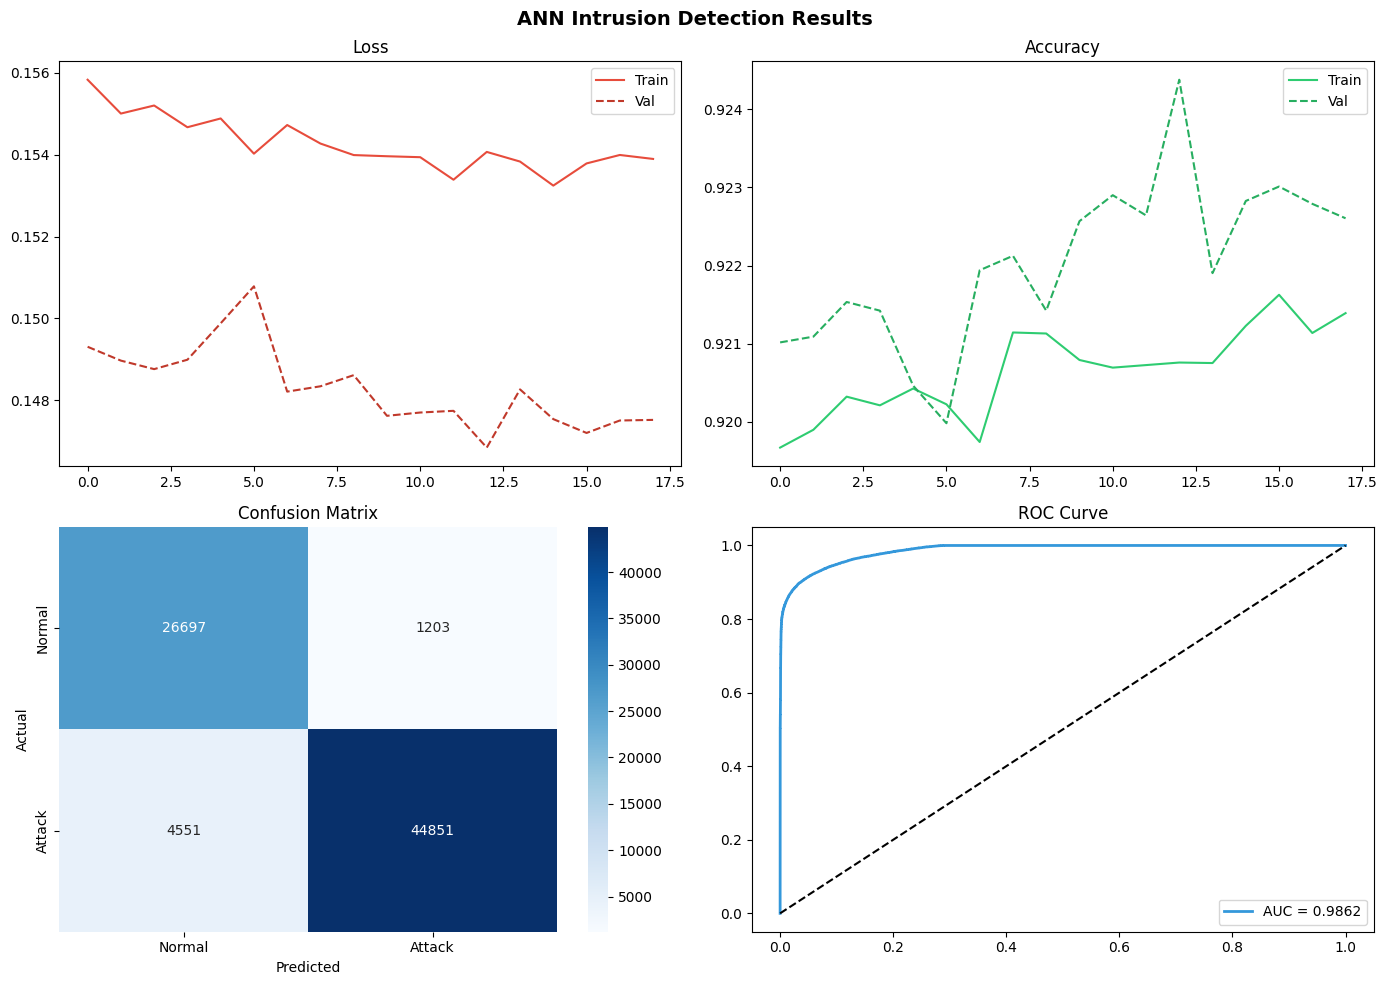

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0,0].plot(history.history['loss'],     label='Train', color='#e74c3c')
axes[0,0].plot(history.history['val_loss'], label='Val',   color='#c0392b', linestyle='--')
axes[0,0].set_title('Loss'); axes[0,0].legend()

# Accuracy
axes[0,1].plot(history.history['accuracy'],     label='Train', color='#2ecc71')
axes[0,1].plot(history.history['val_accuracy'], label='Val',   color='#27ae60', linestyle='--')
axes[0,1].set_title('Accuracy'); axes[0,1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'], ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix')
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score   = roc_auc_score(y_test, y_pred_proba)
axes[1,1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1,1].plot([0,1],[0,1], 'k--')
axes[1,1].set_title('ROC Curve'); axes[1,1].legend()

plt.suptitle('ANN Intrusion Detection Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

model.save('ann_ids_final.keras')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved ✅")
print("Scaler saved ✅")

Model saved ✅
Scaler saved ✅
